In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [2]:
n_class = 4
X, y = make_blobs(n_samples = 1000, n_features = 2, centers = n_class, cluster_std = 1.5, random_state = 42)

In [3]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.LongTensor)

In [4]:
X[:5], y[:5]

(tensor([[-8.4134,  6.9352],
         [-5.7665, -6.4312],
         [-6.0421, -6.7661],
         [ 3.9508,  0.6984],
         [ 4.2505, -0.2815]]),
 tensor([3, 2, 2, 1, 1]))

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)

len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

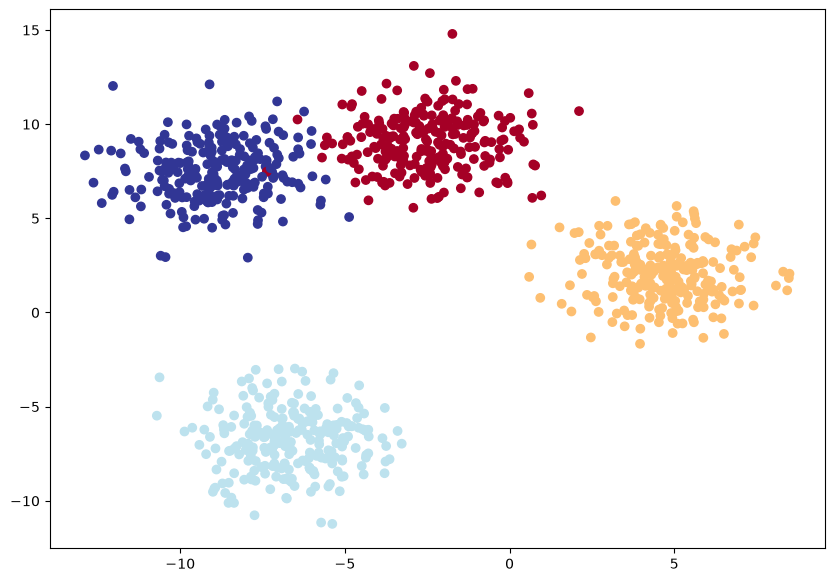

In [6]:
plt.figure(figsize=(10, 7))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

In [7]:
class MulticlassModel(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.layers = torch.nn.Sequential(
            torch.nn.Linear(in_features = 2, out_features = 10),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features = 10, out_features = 10),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features = 10, out_features = 4)
        )

    def forward(self, x):
        return self.layers(x)

In [8]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [9]:
mc_model = MulticlassModel().to(device)
mc_model

MulticlassModel(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): ReLU()
    (4): Linear(in_features=10, out_features=4, bias=True)
  )
)

In [10]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = mc_model.parameters(), lr = 0.1)

In [11]:
torch.manual_seed(42)

epoch = 100

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for ep in range(epoch):

    mc_model.train()

    y_logits = mc_model(X_train)

    y_pred = torch.softmax(y_logits, dim = 1).argmax(dim = 1)

    loss = loss_fn(y_logits, y_train)
    acc = accuracy_score(y_true = y_train.detach().cpu().numpy(), y_pred = y_pred.detach().cpu().numpy())

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    mc_model.eval()

    with torch.inference_mode():

        test_logits = mc_model(X_test)

        test_pred = torch.softmax(test_logits, dim = 1).argmax(dim = 1)

        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_score(y_true = y_test.detach().cpu().numpy(), y_pred = test_pred.detach().cpu().numpy())
        
        if ep % 5 == 0:
            print(f'epoch: {ep}\t||\ttrain BCE loss: {loss:.4f} || acc: {acc:.4f}\t||\ttest loss: {test_loss:.4f} || test acc: {test_acc:.4f}')

epoch: 0	||	train BCE loss: 1.6870 || acc: 0.0887	||	test loss: 1.4338 || test acc: 0.1800
epoch: 5	||	train BCE loss: 1.0600 || acc: 0.5325	||	test loss: 0.9704 || test acc: 0.5400
epoch: 10	||	train BCE loss: 0.7078 || acc: 0.7850	||	test loss: 0.6523 || test acc: 0.8250
epoch: 15	||	train BCE loss: 0.4956 || acc: 0.8850	||	test loss: 0.4545 || test acc: 0.9200
epoch: 20	||	train BCE loss: 0.3421 || acc: 0.9525	||	test loss: 0.3097 || test acc: 0.9750
epoch: 25	||	train BCE loss: 0.2331 || acc: 0.9738	||	test loss: 0.2086 || test acc: 0.9750
epoch: 30	||	train BCE loss: 0.1647 || acc: 0.9825	||	test loss: 0.1471 || test acc: 0.9850
epoch: 35	||	train BCE loss: 0.1240 || acc: 0.9862	||	test loss: 0.1109 || test acc: 0.9850
epoch: 40	||	train BCE loss: 0.0988 || acc: 0.9875	||	test loss: 0.0881 || test acc: 0.9900
epoch: 45	||	train BCE loss: 0.0820 || acc: 0.9888	||	test loss: 0.0730 || test acc: 0.9850
epoch: 50	||	train BCE loss: 0.0707 || acc: 0.9900	||	test loss: 0.0627 || test ac

In [12]:
from helper_functions import plot_predictions, plot_decision_boundary

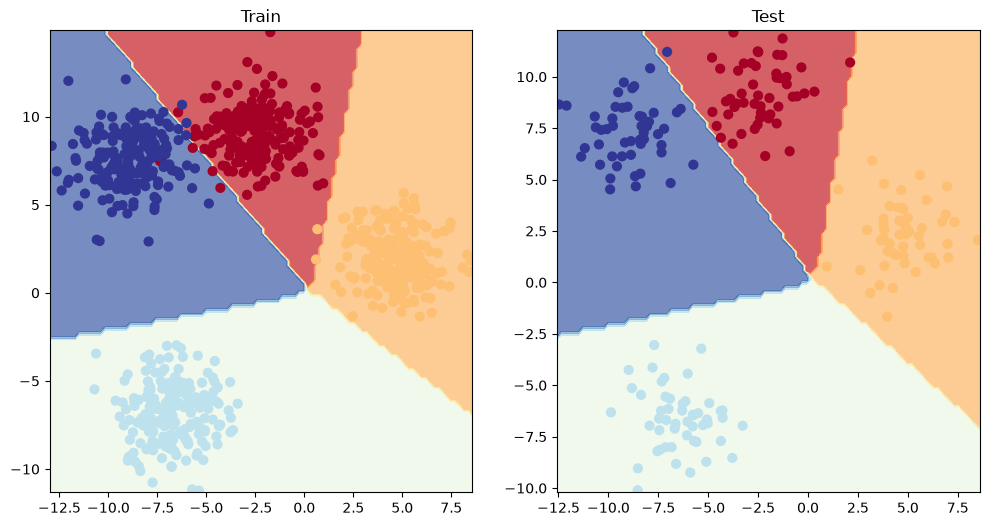

In [13]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(mc_model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(mc_model, X_test, y_test)

In [15]:
from torchmetrics import Accuracy

torchmetrics_accuracy = Accuracy(task='multiclass', num_classes=4).to(device)

# Calculate accuracy
torchmetrics_accuracy(test_pred, y_test)

tensor(0.9950, device='cuda:0')